# Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as  plt
import seaborn as sns
import plotly.express as px
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)



# Loading Dataset

In [2]:
df = pd.read_csv("resolved_tickets.csv")

# Exploratory Data Analysis(EDA)

In [3]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,...,First Response Time,Time to Resolution,Customer Satisfaction Rating,Age Group,Is Resolved,Cleaned_Description,Response Delay (in hours),Resolution Time (in hours),Customer_Response_Pending_Days,Auto_Close
0,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,45-60,True,im facing problem productpurchased productpurc...,25259.243889,6.850000,0.0,False
1,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,18-30,True,im issue productpurchased please assist proble...,22327.494444,-5.533333,0.0,False
2,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,60+,True,im issue productpurchased please assist note s...,29112.211667,19.683333,0.0,False
3,11,Joseph Moreno,mbrown@example.org,48,Male,Nintendo Switch,2021-01-19,Cancellation request,Data loss,I'm having an issue with the {product_purchase...,...,2023-06-01 17:46:49,2023-05-31 23:51:49,1.0,45-60,True,im issue productpurchased please assist produc...,20729.780278,-17.916667,0.0,False
4,12,Brandon Arnold,davisjohn@example.net,51,Male,Microsoft Xbox Controller,2021-10-24,Product inquiry,Software bug,I'm having an issue with the {product_purchase...,...,2023-06-01 12:05:51,2023-06-01 09:27:51,1.0,45-60,True,im issue productpurchased please assist possib...,14052.097500,-2.633333,0.0,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2769 entries, 0 to 2768
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Ticket ID                       2769 non-null   int64  
 1   Customer Name                   2769 non-null   object 
 2   Customer Email                  2769 non-null   object 
 3   Customer Age                    2769 non-null   int64  
 4   Customer Gender                 2769 non-null   object 
 5   Product Purchased               2769 non-null   object 
 6   Date of Purchase                2769 non-null   object 
 7   Ticket Type                     2769 non-null   object 
 8   Ticket Subject                  2769 non-null   object 
 9   Ticket Description              2769 non-null   object 
 10  Ticket Status                   2769 non-null   object 
 11  Resolution                      2769 non-null   object 
 12  Ticket Priority                 27

In [5]:
df['Customer Satisfaction Rating'].value_counts()

Customer Satisfaction Rating
3.0    580
1.0    553
2.0    549
5.0    544
4.0    543
Name: count, dtype: int64

In [6]:
sunburst_data = df.groupby(['Age Group', 'Ticket Type', 'Ticket Subject']).size().reset_index(name='Count')

fig = px.sunburst(
    sunburst_data,
    path=['Age Group', 'Ticket Type', 'Ticket Subject'],
    values='Count',
    title="Sunburst Chart: Ticket Distribution by Age Group, Type, and Subject"
)

fig.update_layout(
    paper_bgcolor="#E6E6FA",.     

          
)
iplot(fig)

# Note: Run all previous cells first, then this one. Hover over the sunburst plot to explore detailed insights.


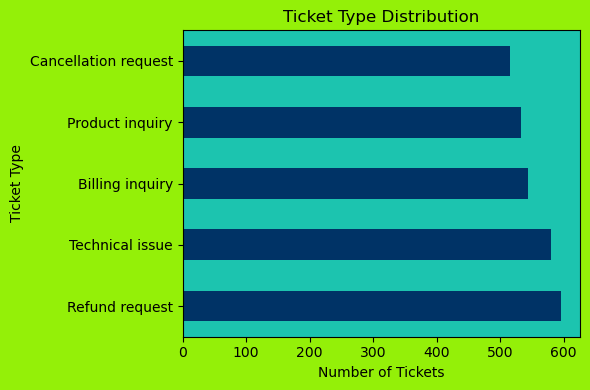

In [7]:
# Counting the number of each ticket type
ticket_counts = df['Ticket Type'].value_counts()

# Plotting  bar chart
plt.figure(figsize=(6,4),facecolor= "#94F008")
ax= ticket_counts.plot(kind='barh',color="#003366")
ax.set_facecolor("#1CC4AF")

# plot
plt.title('Ticket Type Distribution')
plt.xlabel('Number of Tickets')
plt.ylabel('Ticket Type')
plt.tight_layout()
plt.show()

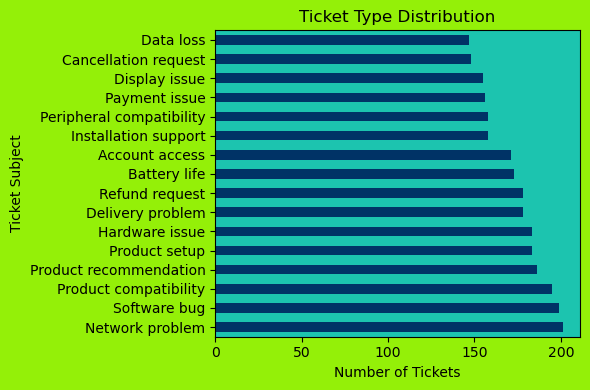

In [8]:
# Counting the number of each ticket subject
ticket_counts = df['Ticket Subject'].value_counts()

# Plotting  bar chart
plt.figure(figsize=(6,4),facecolor= "#94F008")
ax = ticket_counts.plot(kind='barh',color="#003366")
ax.set_facecolor("#1CC4AF")

# plot
plt.title('Ticket Type Distribution')
plt.xlabel('Number of Tickets')
plt.ylabel('Ticket Subject')
plt.tight_layout()
plt.show()

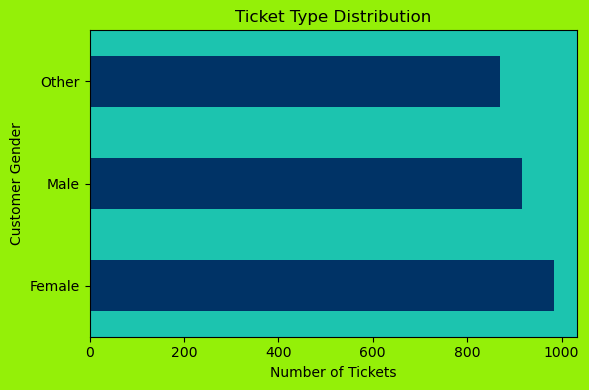

In [9]:
# Counting Gender
ticket_counts = df['Customer Gender'].value_counts()

# Plotting bar chart
plt.figure(figsize=(6,4),facecolor= "#94F008")
ax = ticket_counts.plot(kind='barh',color="#003366")
ax.set_facecolor("#1CC4AF")

# plot
plt.title('Ticket Type Distribution')
plt.xlabel('Number of Tickets')
plt.ylabel('Customer Gender')
plt.tight_layout()
plt.show()

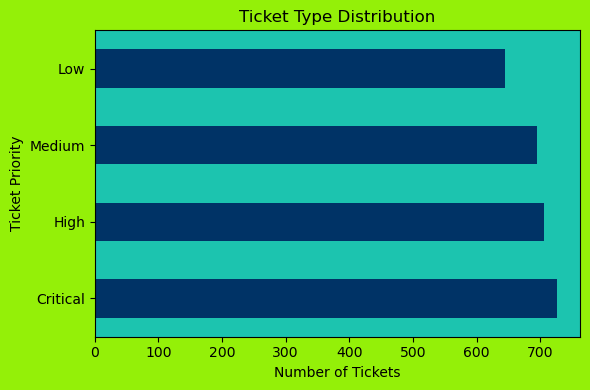

In [10]:
# Count the number of each ticket priority
ticket_counts = df['Ticket Priority'].value_counts()

# Plotting bar chart
plt.figure(figsize=(6,4),facecolor= "#94F008")
ax = ticket_counts.plot(kind='barh',color="#003366")
ax.set_facecolor("#1CC4AF")

# plot
plt.title('Ticket Type Distribution')
plt.xlabel('Number of Tickets')
plt.ylabel('Ticket Priority')
plt.tight_layout()
plt.show()

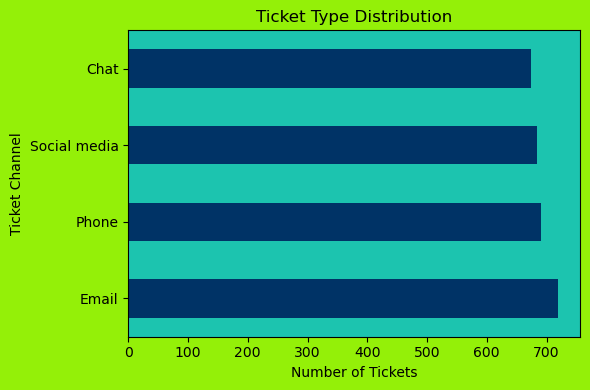

In [11]:
# Count the number of each ticket channel
ticket_counts = df['Ticket Channel'].value_counts()

# Plotting bar chart
plt.figure(figsize=(6,4),facecolor= "#94F008")
ax = ticket_counts.plot(kind='barh',color="#003366")
ax.set_facecolor("#1CC4AF")

# plot
plt.title('Ticket Type Distribution')
plt.xlabel('Number of Tickets')
plt.ylabel('Ticket Channel')
plt.tight_layout()
plt.show()

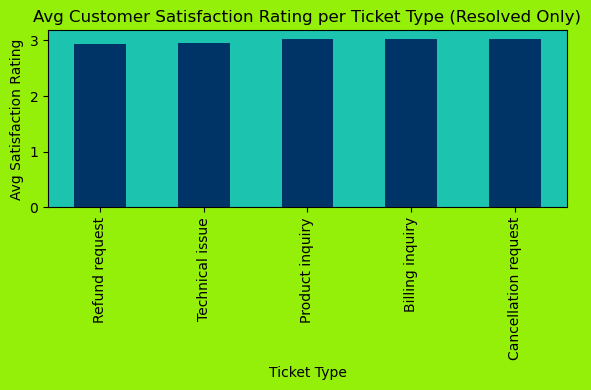

In [12]:
resolved_df = df[df['Is Resolved'] == True]

# Grouping by Ticket Type and calculating average satisfaction rating
avg_rating = resolved_df.groupby('Ticket Type')['Customer Satisfaction Rating'].mean().sort_values()

# Plotting bar chart
plt.figure(figsize=(6, 4), facecolor="#94F008")
ax = avg_rating.plot(kind='bar', color="#003366")
ax.set_facecolor("#1CC4AF")

# plot
plt.title('Avg Customer Satisfaction Rating per Ticket Type (Resolved Only)')
plt.ylabel('Avg Satisfaction Rating')
plt.xlabel('Ticket Type')
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

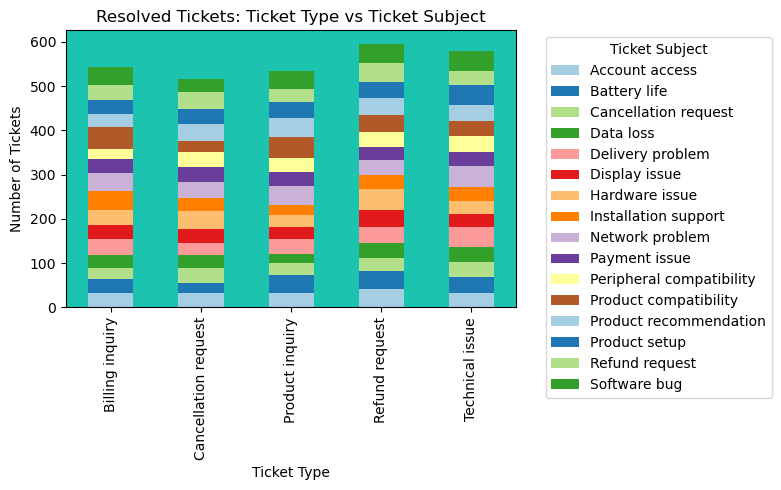

In [13]:
# Filtered only resolved tickets
resolved_df = df[df['Is Resolved'] == True]

# Grouped by Ticket Type and Ticket Subject  count
grouped = resolved_df.groupby(['Ticket Type', 'Ticket Subject']).size().unstack(fill_value=0)

# Plotting stacked bar chart
plt.figure(figsize=(8, 5), facecolor="#94F008")
ax = grouped.plot(kind='bar', stacked=True, figsize=(8, 5), color=plt.cm.Paired.colors)
ax.set_facecolor("#1CC4AF")

#plot
plt.legend(title="Ticket Subject", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Resolved Tickets: Ticket Type vs Ticket Subject')
plt.xlabel('Ticket Type')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()


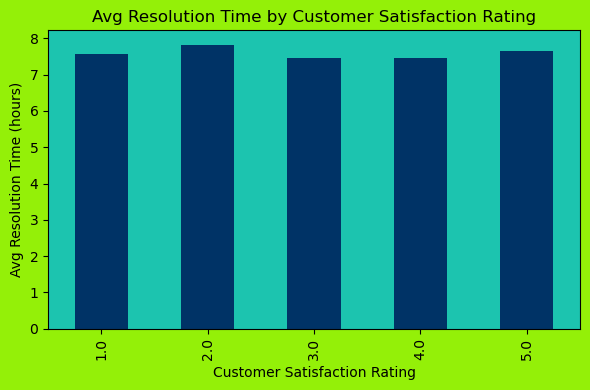

In [14]:
# Filtered only resolved tickets with positive resolution time
filtered_df = df[(df['Is Resolved'] == True) & (df['Resolution Time (in hours)'] > 0)]

# Grouped by Customer Satisfaction Rating and calculated average resolution time
avg_resolution = filtered_df.groupby('Customer Satisfaction Rating')['Resolution Time (in hours)'].mean()

# Plot 
plt.figure(figsize=(6, 4), facecolor="#94F008")
ax = avg_resolution.plot(kind='bar', color="#003366")
ax.set_facecolor("#1CC4AF")

plt.title('Avg Resolution Time by Customer Satisfaction Rating')
plt.xlabel('Customer Satisfaction Rating')
plt.ylabel('Avg Resolution Time (hours)')
plt.tight_layout()
plt.show()

<div style="background-color:#d4edda; color:#155724; padding:20px; border-radius:10px; font-family:Arial, sans-serif;">

  <h2 style="color:#1b4d1b;">Summary of Resolved Ticket Data (Elderly Users Focus)</h2>

  <p><b>What we found:</b><br>
  Elderly users experience the most issues compared to other age groups. Most of their problems are related to <b>technical issues</b> (like software bugs, setup, compatibility) and <b>refund requests</b> (payment and refund processing).</p>

  <p><b>What this means:</b><br>
  Elderly users may face difficulties with complex processes, highlighting the need for improved support tailored to their needs.</p>

 <p><b>What we can do:</b></p>
<ul style="color:#155724;">
  <li>We can implement a <b>chatbot</b> that guides users through common issues like technical problems, product enquiry etc... This will streamline support and be especially helpful for elderly users who may struggle with complex navigation or waiting for responses.</li>
  <li>We can enhance the <b>Help Section</b> by adding a clearly visible, easy-to-understand FAQ page that addresses frequently raised concerns.</li>
  <li>Both the chatbot and the improved help section can empower users to find answers on their own, reducing the number of tickets raised and allowing the support team to focus on more critical cases.</li>
</ul>


  <p><b>Customer Ratings Insight:</b><br>
  Elderly users tend to give lower satisfaction ratings due to delays or unresolved issues. Providing quick access to solutions will help increase their satisfaction and reduce frustration.</p>

</div>

